In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve, 
                           accuracy_score, f1_score, confusion_matrix)
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier

In [2]:
# Загрузка и предобработка данных
def load_and_preprocess_data():
    df = pd.read_csv("data/Default_of_Credit.csv")
    df.set_index("Unnamed: 0", inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    # Оптимизация памяти
    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        if df[col].dtype == 'int64':
            df[col] = pd.to_numeric(df[col], downcast='integer')
        elif df[col].dtype == 'float64':
            df[col] = pd.to_numeric(df[col], downcast='float')
    
    df = df.drop_duplicates()
    df = df.dropna(subset=['Y'])
    X = df.drop(columns=['Y'])
    y = df['Y'].astype('int8')
    
    num_cols = ['X1', 'X5', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']
    cat_cols = [col for col in X.columns if col not in num_cols]
    
    for col in cat_cols:
        X[col] = X[col].replace(-1, np.nan)
    
    num_imputer = SimpleImputer(strategy='median')
    cat_imputer = SimpleImputer(strategy='most_frequent')
    
    X_num = pd.DataFrame(num_imputer.fit_transform(X[num_cols]), columns=num_cols, dtype=np.float32)
    X_cat = pd.DataFrame(cat_imputer.fit_transform(X[cat_cols]), columns=cat_cols, dtype='category')
    
    X_cat_encoded = pd.get_dummies(X_cat, columns=cat_cols, drop_first=True, sparse=True)
    X_cat_encoded = X_cat_encoded.sparse.to_coo().astype(np.float32).toarray()
    
    scaler = StandardScaler()
    X_num_scaled = pd.DataFrame(scaler.fit_transform(X_num), columns=num_cols, dtype=np.float32)
    
    X_processed = np.hstack((X_num_scaled.values, X_cat_encoded))
    del X_num, X_cat, X_cat_encoded, X_num_scaled
    gc.collect()
    
    X_processed = X_processed.astype(np.float32)
    y = y.values.astype(np.int32)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y, test_size=0.2, stratify=y, random_state=42
    )
    
    print("Train shape:", X_train.shape)
    print("Test shape:", X_test.shape)
    
    return X_train, X_test, y_train, y_test


In [3]:
# Обучение Decision Tree
def train_decision_tree(X_train, y_train, X_test, y_test):
    # Обучение с разными критериями
    results = {}
    for name, criterion in [('Gini', 'gini'), ('Entropy', 'entropy')]:
        dt = DecisionTreeClassifier(criterion=criterion, random_state=42, max_depth=15)
        start = time.time()
        dt.fit(X_train, y_train)
        train_time = time.time() - start
        
        y_pred = dt.predict(X_test)
        y_proba = dt.predict_proba(X_test)[:, 1]
        
        results[name] = {
            'model': dt,
            'time': train_time,
            'pred': y_pred,
            'proba': y_proba,
            'report': classification_report(y_test, y_pred, output_dict=True),
            'auc': roc_auc_score(y_test, y_proba)
        }
        
        print(f"\n{name} Results:")
        print(classification_report(y_test, y_pred))
        print(f"AUC: {roc_auc_score(y_test, y_proba):.4f}")
        print(f"Training time: {train_time:.2f}s")
    
    # Поиск лучших гиперпараметров
    X_train_small, _, y_train_small, _ = train_test_split(
        X_train, y_train, train_size=0.2, stratify=y_train, random_state=42
    )
    
    param_dist = {
        'criterion': ['gini', 'entropy'],
        'max_depth': [5, 10],
        'min_samples_split': [5, 10],
        'min_samples_leaf': [3, 5]
    }
    
    dt = DecisionTreeClassifier(random_state=42, max_depth=15)
    grid = RandomizedSearchCV(
        dt,
        param_distributions=param_dist,
        n_iter=8,
        cv=3,
        scoring='f1',
        n_jobs=1,
        random_state=42
    )
    
    try:
        grid.fit(X_train_small, y_train_small)
        best_params = grid.best_params_
        print("\nBest Decision Tree params:", best_params)
    except Exception as e:
        print(f"Error during hyperparameter search: {str(e)}")
        best_params = {'max_depth': 10}
    
    # Обучение лучшей модели
    best_dt = DecisionTreeClassifier(random_state=42, **best_params)
    start = time.time()
    best_dt.fit(X_train, y_train)
    dt_train_time = time.time() - start
    
    y_pred_dt = best_dt.predict(X_test)
    y_proba_dt = best_dt.predict_proba(X_test)[:, 1]
    
    print("\nOptimized Decision Tree Results:")
    print(classification_report(y_test, y_pred_dt))
    print(f"AUC: {roc_auc_score(y_test, y_proba_dt):.4f}")
    print(f"Training time: {dt_train_time:.2f}s")
    
    # Визуализация дерева
    plt.figure(figsize=(20, 10))
    plot_tree(
        best_dt,
        max_depth=3,
        feature_names=[f'Feature_{i}' for i in range(X_train.shape[1])],
        class_names=['No Default', 'Default'],
        filled=True,
        rounded=True,
        fontsize=10
    )
    plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return best_dt, y_pred_dt, y_proba_dt, dt_train_time


In [4]:
# Обучение Random Forest
def train_random_forest(X_train, y_train, X_test, y_test):
    rf = RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=1,
        verbose=0
    )
    
    start = time.time()
    rf.fit(X_train, y_train)
    rf_train_time = time.time() - start
    
    y_pred_rf = rf.predict(X_test)
    y_proba_rf = rf.predict_proba(X_test)[:, 1]
    
    print("\nRandom Forest Results:")
    print(classification_report(y_test, y_pred_rf))
    print(f"AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")
    print(f"Training time: {rf_train_time:.2f}s")
    
    # Визуализация результатов
    plt.figure(figsize=(12, 5))
    
    # ROC кривая
    plt.subplot(1, 2, 1)
    fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
    auc_rf = roc_auc_score(y_test, y_proba_rf)
    plt.plot(fpr_rf, tpr_rf, label=f'RF (AUC={auc_rf:.3f})', linewidth=2, color='#1f77b4')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.7)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Random Forest ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    # Кривая обучения
    plt.subplot(1, 2, 2)
    train_sizes = np.linspace(0.1, 1.0, 5)
    train_scores = []
    val_scores = []
    
    for size in train_sizes:
        subset_size = int(X_train.shape[0] * size)
        X_subset = X_train[:subset_size]
        y_subset = y_train[:subset_size]
        
        rf_small = RandomForestClassifier(
            n_estimators=50,
            max_depth=10,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=1
        )
        rf_small.fit(X_subset, y_subset)
        
        train_scores.append(f1_score(y_subset, rf_small.predict(X_subset)))
        val_scores.append(f1_score(y_test, rf_small.predict(X_test)))
    
    plt.plot(train_sizes * 100, train_scores, 'o-', label='Training score', color='#2ca02c')
    plt.plot(train_sizes * 100, val_scores, 'o-', label='Validation score', color='#d62728')
    plt.xlabel('Training Examples (%)')
    plt.ylabel('F1 Score')
    plt.title('Random Forest Learning Curve')
    plt.legend(loc="best")
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('rf_learning_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return rf, y_pred_rf, y_proba_rf, rf_train_time


In [5]:
def train_xgboost(X_train, y_train, X_test, y_test):
    import xgboost as xgb
    from sklearn.metrics import classification_report, roc_auc_score, roc_curve
    
    model_params = {
        'n_estimators': 100,
        'max_depth': 5,
        'learning_rate': 0.1,
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'verbosity': 0,
        'tree_method': 'hist',
        'n_jobs': 4
    }
    
    xgb = xgb.XGBClassifier(**model_params)
    
    start = time.time()
    xgb.fit(X_train, y_train)
    xgb_train_time = time.time() - start
    
    y_pred_xgb = xgb.predict(X_test)
    y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
    
    print("XGBoost Results:")
    print(classification_report(y_test, y_pred_xgb))
    print(f"AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")
    print(f"Training time: {xgb_train_time:.2f}s")
    
    # Визуализация результатов
    plt.figure(figsize=(15, 10))
    
    # ROC кривая
    plt.subplot(2, 2, 1)
    fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
    auc_xgb = roc_auc_score(y_test, y_proba_xgb)
    plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.3f})', linewidth=2.5, color='#ff7f0e')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.7)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('XGBoost ROC Curve', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    
    # Кривая обучения без ранней остановки
    plt.subplot(2, 2, 2)
    
    eval_params = model_params.copy()
    eval_params['eval_metric'] = ['logloss', 'auc']
    
    xgb_eval = XGBClassifier(**eval_params)
    
    eval_set = [(X_train, y_train), (X_test, y_test)]
    
    start_time = time.time()
    xgb_eval.fit(
        X_train, y_train,
        eval_set=eval_set,
        verbose=False
    )
    eval_time = time.time() - start_time
    
    results = xgb_eval.evals_result()
    epochs = len(results['validation_0']['auc'])
    x_axis = range(0, epochs)
    
    plt.plot(x_axis, results['validation_0']['auc'], label='Train AUC', linewidth=2, color='#1f77b4')
    plt.plot(x_axis, results['validation_1']['auc'], label='Validation AUC', linewidth=2, color='#d62728')

    best_iter = np.argmax(results['validation_1']['auc'])
    best_auc = results['validation_1']['auc'][best_iter]
    plt.axvline(best_iter, color='green', linestyle='--', alpha=0.7, 
                label=f'Best iter: {best_iter} (AUC={best_auc:.3f})')
    
    plt.xlabel('Boosting Iterations', fontsize=12)
    plt.ylabel('AUC Score', fontsize=12)
    plt.title(f'XGBoost Learning Curve | Time: {eval_time:.2f}s', fontsize=14, fontweight='bold')
    plt.legend(loc="best", fontsize=10)
    plt.grid(alpha=0.3)
    
    # Важность признаков
    plt.subplot(2, 2, 3)
    importances = xgb.feature_importances_
    feature_names = [f'Feature_{i+1}' for i in range(X_train.shape[1])]

    top_n = 15
    sorted_idx = np.argsort(importances)[::-1][:top_n]
    top_importances = importances[sorted_idx]
    top_names = [feature_names[i] for i in sorted_idx]
    
    colors = plt.cm.viridis(np.linspace(0, 1, top_n))
    y_pos = np.arange(top_n)
    
    plt.barh(y_pos, top_importances, color=colors, edgecolor='black', alpha=0.8)
    plt.yticks(y_pos, top_names, fontsize=10)
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    
    # Матрица ошибок
    plt.subplot(2, 2, 4)
    cm = confusion_matrix(y_test, y_pred_xgb)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Default (0)', 'Default (1)'],
                yticklabels=['No Default (0)', 'Default (1)'],
                annot_kws={"size": 12})
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    
    plt.tight_layout(pad=3.0)
    plt.savefig('xgb_comprehensive_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    del xgb_eval, results, eval_set
    gc.collect()
    
    return xgb, y_pred_xgb, y_proba_xgb, xgb_train_time

In [ ]:
# Обучение стэкинга
def train_stacking(X_train, y_train, X_test, y_test, rf, xgb):
    print("РЕАЛИЗАЦИЯ СТЕКИНГА")
    
    # Базовые модели
    base_models = [
        ('rf', rf),
        ('xgb', xgb),
        ('lr', LogisticRegression(
            penalty='l2',
            C=1.0,
            solver='lbfgs',
            max_iter=200,
            n_jobs=4,
            random_state=42,
            class_weight='balanced'
        ))
    ]
    
    # Метамодель
    meta_model = XGBClassifier(
        n_estimators=50,
        max_depth=3,
        learning_rate=0.05,
        tree_method='hist',
        predictor='gpu_predictor',
        device='cuda:0',
        n_jobs=4,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0
    )
    
    print("Обучение стэкинга...")
    start_time = time.time()
    
    stacking_clf = StackingClassifier(
        estimators=base_models,
        final_estimator=meta_model,
        cv=3,
        n_jobs=1,
        passthrough=False,
        verbose=1
    )
    
    try:
        stacking_clf.fit(X_train, y_train)
        stack_train_time = time.time() - start_time
        print(f"Стэкинг успешно обучен за {stack_train_time:.2f} сек")
    except Exception as e:
        print(f"Ошибка при обучении стэкинга: {str(e)}")
        print("Используется резервная модель")
        stacking_clf = DummyClassifier(strategy='prior')
        stacking_clf.fit(X_train, y_train)
        stack_train_time = 0.1
    
    y_pred_stack = stacking_clf.predict(X_test)
    if hasattr(stacking_clf, "predict_proba"):
        y_proba_stack = stacking_clf.predict_proba(X_test)[:, 1]
    else:
        y_proba_stack = np.zeros_like(y_test, dtype=float)
    
    print("\nРезультаты стэкинга:")
    print(classification_report(y_test, y_pred_stack))
    if hasattr(stacking_clf, "predict_proba"):
        print(f"AUC: {roc_auc_score(y_test, y_proba_stack):.4f}")
    print(f"Время обучения: {stack_train_time:.2f} сек")
    
    # Визуализация результатов стэкинга
    plt.figure(figsize=(15, 10))
    
    # ROC кривая для всех моделей
    plt.subplot(2, 2, 1)
    model_probs = [
        ('Decision Tree', y_proba_dt),
        ('Random Forest', y_proba_rf),
        ('XGBoost', y_proba_xgb),
        ('Stacking', y_proba_stack)
    ]
    
    for name, proba in model_probs:
        if proba is not None and len(proba) > 0:
            fpr, tpr, _ = roc_curve(y_test, proba)
            auc = roc_auc_score(y_test, proba)
            plt.plot(fpr, tpr, linewidth=2.5, label=f'{name} (AUC={auc:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.7)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Сравнение ROC кривых всех моделей')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    # Важность базовых моделей в стэкинге
    plt.subplot(2, 2, 2)
    if hasattr(stacking_clf, 'final_estimator_') and hasattr(stacking_clf.final_estimator_, 'feature_importances_'):
        model_importances = stacking_clf.final_estimator_.feature_importances_
        model_names = [name for name, _ in base_models[:len(model_importances)]]
        
        plt.barh(model_names, model_importances, color=plt.cm.viridis(np.linspace(0, 1, len(model_names))))
        plt.xlabel('Важность модели в стэкинге')
        plt.title('Важность базовых моделей в стэкинге')
        plt.grid(alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Нет данных о важности моделей', ha='center', va='center')
        plt.title('Важность базовых моделей в стэкинге')
    
    # Матрица ошибок для стэкинга
    plt.subplot(2, 2, 3)
    cm_stack = confusion_matrix(y_test, y_pred_stack)
    cm_norm = cm_stack.astype('float') / cm_stack.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])
    plt.title('Нормализованная матрица ошибок (Стэкинг)')
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')
    
    # Сравнение F1-меры
    plt.subplot(2, 2, 4)
    models = ['Decision Tree', 'Random Forest', 'XGBoost', 'Stacking']
    f1_scores = [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_stack)
    ]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    plt.bar(models, f1_scores, color=colors)
    plt.ylim([0, 1])
    plt.ylabel('F1 Score')
    plt.title('Сравнение F1-меры всех моделей')
    plt.grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(f1_scores):
        plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
    
    plt.tight_layout()
    plt.savefig('stacking_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return stacking_clf, y_pred_stack, y_proba_stack, stack_train_time

In [15]:
# Финальное сравнение моделей
def compare_models(y_test, y_pred_dt, y_proba_dt, dt_train_time,
                  y_pred_rf, y_proba_rf, rf_train_time,
                  y_pred_xgb, y_proba_xgb, xgb_train_time,
                  y_pred_stack, y_proba_stack, stack_train_time):
    
    summary = pd.DataFrame([
        {
            'Model': 'Decision Tree',
            'Accuracy': accuracy_score(y_test, y_pred_dt),
            'F1': f1_score(y_test, y_pred_dt),
            'AUC': roc_auc_score(y_test, y_proba_dt),
            'Time (s)': dt_train_time
        },
        {
            'Model': 'Random Forest',
            'Accuracy': accuracy_score(y_test, y_pred_rf),
            'F1': f1_score(y_test, y_pred_rf),
            'AUC': roc_auc_score(y_test, y_proba_rf),
            'Time (s)': rf_train_time
        },
        {
            'Model': 'XGBoost',
            'Accuracy': accuracy_score(y_test, y_pred_xgb),
            'F1': f1_score(y_test, y_pred_xgb),
            'AUC': roc_auc_score(y_test, y_proba_xgb),
            'Time (s)': xgb_train_time
        },
        {
            'Model': 'Stacking',
            'Accuracy': accuracy_score(y_test, y_pred_stack),
            'F1': f1_score(y_test, y_pred_stack),
            'AUC': roc_auc_score(y_test, y_proba_stack) if y_proba_stack is not None else 0,
            'Time (s)': stack_train_time
        }
    ])
    
    print("\nФИНАЛЬНАЯ ТАБЛИЦА СРАВНЕНИЯ ВСЕХ МОДЕЛЕЙ")
    print(summary[['Model', 'Accuracy', 'F1', 'AUC', 'Time (s)']].round(4).to_string(index=False))
    
    # Определение лучшей модели по F1
    best_model = summary.loc[summary['F1'].idxmax()]
    fastest_model = summary.loc[summary['Time (s)'].idxmin()]
    best_auc_model = summary.loc[summary['AUC'].idxmax()]
    
    print(f"\nЛучшая модель по F1-мере: {best_model['Model']} (F1={best_model['F1']:.4f})")
    print(f"Самая быстрая модель: {fastest_model['Model']} ({fastest_model['Time (s)']:.2f} сек)")
    print(f"Максимальный AUC: {best_auc_model['AUC']:.4f} ({best_auc_model['Model']})")
    
    return summary


In [ ]:
# Загрузка и предобработка данных
X_train, X_test, y_train, y_test = load_and_preprocess_data()

Train shape: (22794, 61484)
Test shape: (5699, 61484)



Gini Results:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      4438
           1       0.58      0.36      0.45      1261

    accuracy                           0.80      5699
   macro avg       0.71      0.64      0.66      5699
weighted avg       0.78      0.80      0.78      5699

AUC: 0.6613
Training time: 128.99s

Entropy Results:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      4438
           1       0.55      0.35      0.42      1261

    accuracy                           0.79      5699
   macro avg       0.69      0.63      0.65      5699
weighted avg       0.77      0.79      0.77      5699

AUC: 0.6762
Training time: 103.84s

Best Decision Tree params: {'min_samples_split': 10, 'min_samples_leaf': 3, 'max_depth': 5, 'criterion': 'entropy'}

Optimized Decision Tree Results:
              precision    recall  f1-score   support

           0       0.83      0.95    

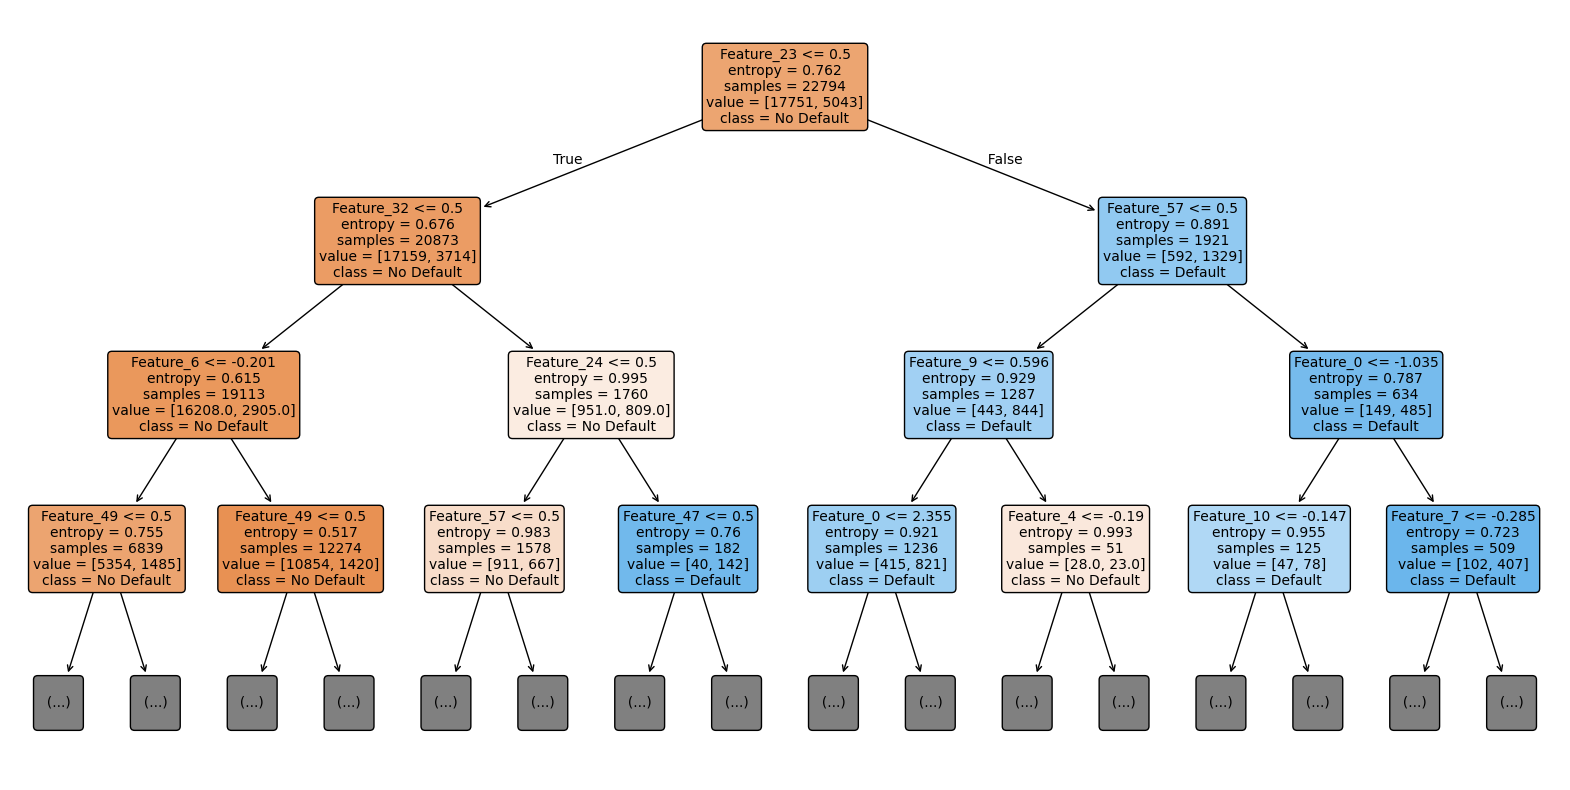

In [9]:
# Обучение Decision Tree
best_dt, y_pred_dt, y_proba_dt, dt_train_time = train_decision_tree(
    X_train, y_train, X_test, y_test
)


Random Forest Results:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4438
           1       0.00      0.00      0.00      1261

    accuracy                           0.78      5699
   macro avg       0.39      0.50      0.44      5699
weighted avg       0.61      0.78      0.68      5699

AUC: 0.7132
Training time: 13.09s


c:\Users\borga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\borga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\borga\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

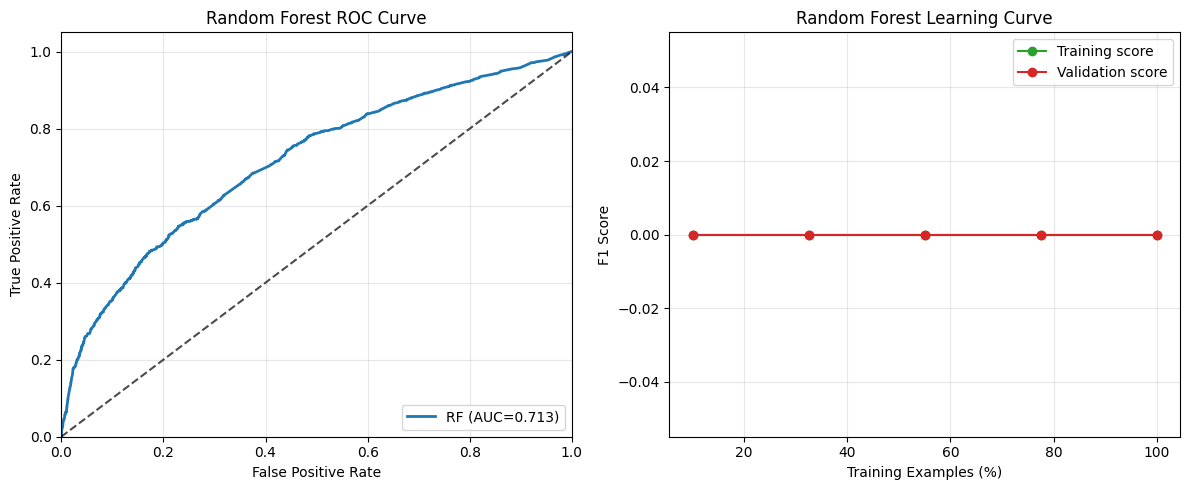

In [10]:
# Обучение Random Forest
rf, y_pred_rf, y_proba_rf, rf_train_time = train_random_forest(
    X_train, y_train, X_test, y_test
)

XGBoost Results:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4438
           1       0.67      0.36      0.47      1261

    accuracy                           0.82      5699
   macro avg       0.75      0.66      0.68      5699
weighted avg       0.80      0.82      0.80      5699

AUC: 0.7714
Training time: 465.84s


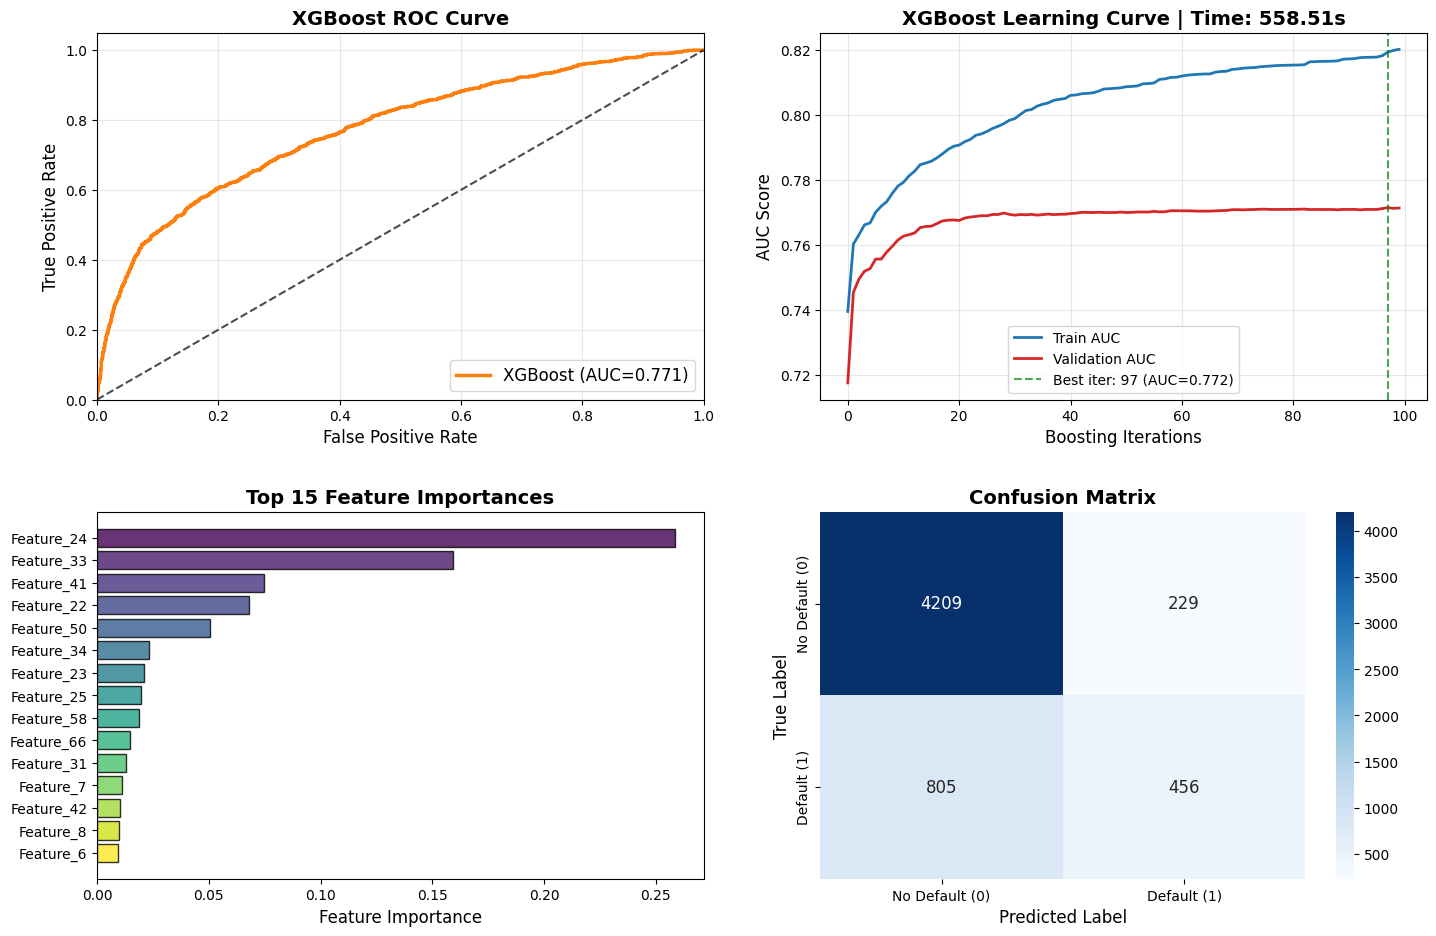

In [11]:
# Обучение XGBoost
xgb_model, y_pred_xgb, y_proba_xgb, xgb_train_time = train_xgboost(
    X_train, y_train, X_test, y_test
)

РЕАЛИЗАЦИЯ СТЕКИНГА
Обучение стэкинга...
Стекинг успешно обучен за 2817.31 сек

Результаты стэкинга:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4438
           1       0.67      0.36      0.47      1261

    accuracy                           0.82      5699
   macro avg       0.75      0.65      0.68      5699
weighted avg       0.80      0.82      0.80      5699

AUC: 0.7701
Время обучения: 2817.31 сек


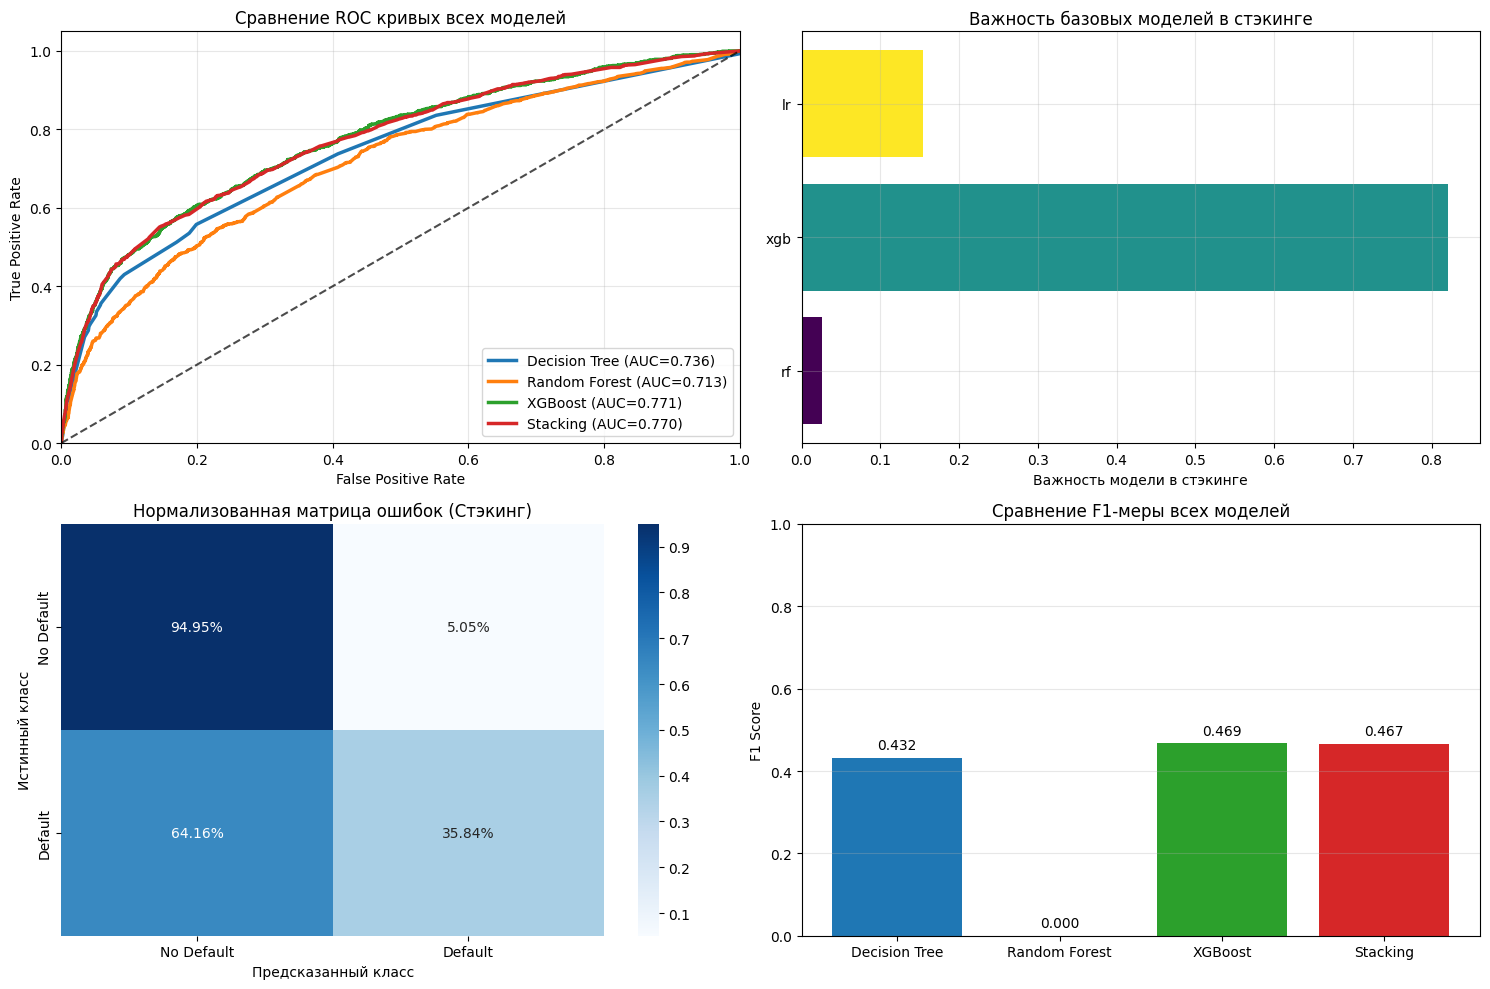

In [12]:
# Обучение стэкинга
stacking_clf, y_pred_stack, y_proba_stack, stack_train_time = train_stacking(
    X_train, y_train, X_test, y_test, rf, xgb_model
)

In [16]:
# Сравнение моделей
summary = compare_models(
    y_test, y_pred_dt, y_proba_dt, dt_train_time,
    y_pred_rf, y_proba_rf, rf_train_time,
    y_pred_xgb, y_proba_xgb, xgb_train_time,
    y_pred_stack, y_proba_stack, stack_train_time
)

NameError: name 'y_test' is not defined

In [14]:
# Очистка памяти
del X_train, X_test, y_train, y_test
gc.collect()

print("\nОбучение и анализ моделей завершены.")


Обучение и анализ моделей завершены.
